In [1]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)

TensorFlow: 2.13.0


In [2]:
from pathlib import Path

import numpy as np
import cv2
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
IMAGE_DIR = Path("../data/images")
MASK_DIR = Path("../data/masks")

print("Image directory:", IMAGE_DIR)
print("Mask directory:", MASK_DIR)

Image directory: ..\data\images
Mask directory: ..\data\masks


In [4]:
image_paths = sorted(IMAGE_DIR.glob("*.jpg"))

print("Number of images:", len(image_paths))

Number of images: 900


In [5]:
mask_paths = sorted(MASK_DIR.glob("*.png"))

print("Number of masks:", len(mask_paths))

Number of masks: 900


In [6]:
image_path = image_paths[0]

print("Image path:")
print(image_path)

Image path:
..\data\images\ISIC_0000000.jpg


In [ ]:
# corrosponding mask
image_id = image_path.stem

mask_path = MASK_DIR / f"{image_id}_Segmentation.png"

print("Image ID:", image_id)
print("Mask path:", mask_path)
print("Mask exists:", mask_path.exists())

Image ID: ISIC_0000000
Mask path: ..\data\masks\ISIC_0000000_Segmentation.png
Mask exists: True


## Load the image

In [8]:
image = cv2.imread(str(image_path))

print("Image shape:", image.shape)
print("Image data type:", image.dtype)

Image shape: (767, 1022, 3)
Image data type: uint8


In [9]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print("RGB image shape:", image_rgb.shape)

RGB image shape: (767, 1022, 3)


In [10]:
mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

print("Mask shape:", mask.shape)
print("Mask data type:", mask.dtype)

Mask shape: (767, 1022)
Mask data type: uint8


In [11]:
unique_values = np.unique(mask)

print("Unique pixel values in mask:", unique_values)

Unique pixel values in mask: [  0 255]


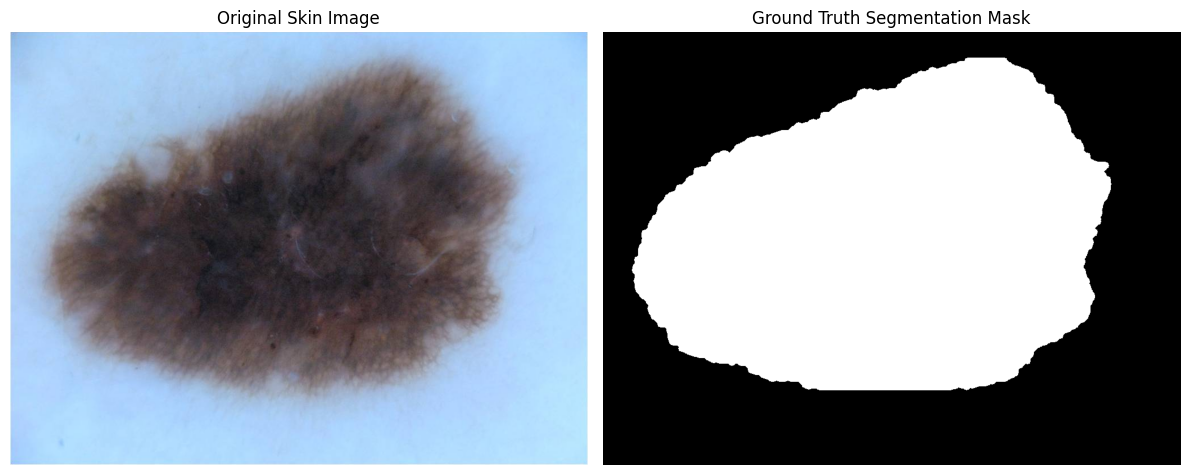

In [12]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Skin Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("Ground Truth Segmentation Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

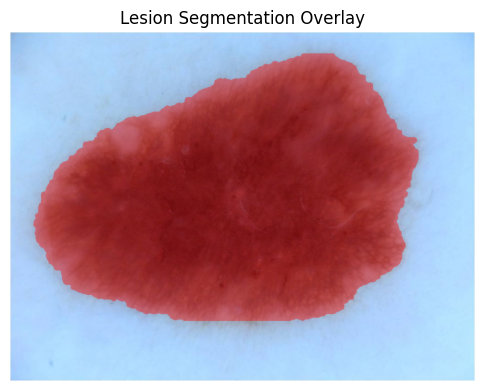

In [13]:
# Create a colored overlay of the segmentation mask

overlay = image_rgb.copy()

# Create a red mask
red_mask = np.zeros_like(image_rgb)
red_mask[:, :, 0] = 255

# Apply the red color only where the lesion exists
mask_binary = mask > 0
overlay[mask_binary] = red_mask[mask_binary]

# Blend original image and overlay
blended = cv2.addWeighted(image_rgb, 0.6, overlay, 0.4, 0)

plt.figure(figsize=(6, 6))

plt.imshow(blended)
plt.title("Lesion Segmentation Overlay")
plt.axis("off")

plt.show()

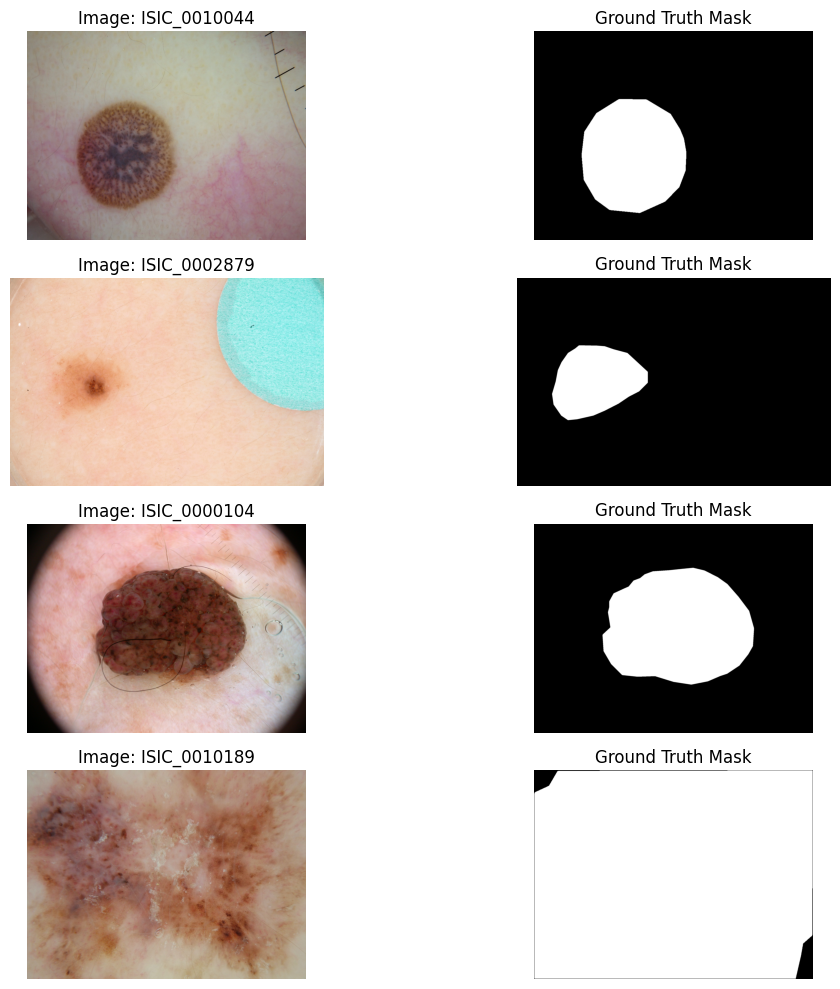

In [14]:
#lets visualize random sample
import random

random_indices = random.sample(range(len(image_paths)), 4)

plt.figure(figsize=(12, 10))

for i, idx in enumerate(random_indices):

    # Load image
    image_path = image_paths[idx]
    image = cv2.imread(str(image_path))
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Find corresponding mask
    image_id = image_path.stem
    mask_path = MASK_DIR / f"{image_id}_Segmentation.png"

    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

    # Image
    plt.subplot(4, 2, 2*i + 1)
    plt.imshow(image_rgb)
    plt.title(f"Image: {image_id}")
    plt.axis("off")

    # Mask
    plt.subplot(4, 2, 2*i + 2)
    plt.imshow(mask, cmap="gray")
    plt.title("Ground Truth Mask")
    plt.axis("off")

plt.tight_layout()
plt.show()

## checking dimensions

In [15]:
# Check dimensions of several images

for i in range(5):
    image_path = image_paths[i]

    image = cv2.imread(str(image_path))
    
    print(
        image_path.stem,
        "→",
        image.shape
    )

ISIC_0000000 → (767, 1022, 3)
ISIC_0000001 → (767, 1022, 3)
ISIC_0000002 → (767, 1022, 3)
ISIC_0000004 → (767, 1022, 3)
ISIC_0000006 → (767, 1022, 3)


In [16]:
# Check dimensions of several masks

for i in range(5):
    image_path = image_paths[i]

    image_id = image_path.stem
    mask_path = MASK_DIR / f"{image_id}_Segmentation.png"

    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

    print(
        image_id,
        "→ Image:",
        image_paths[i].name,
        "| Mask:",
        mask.shape
    )

ISIC_0000000 → Image: ISIC_0000000.jpg | Mask: (767, 1022)
ISIC_0000001 → Image: ISIC_0000001.jpg | Mask: (767, 1022)
ISIC_0000002 → Image: ISIC_0000002.jpg | Mask: (767, 1022)
ISIC_0000004 → Image: ISIC_0000004.jpg | Mask: (767, 1022)
ISIC_0000006 → Image: ISIC_0000006.jpg | Mask: (767, 1022)


In [17]:
# Calculate lesion coverage for the first 5 images

for i in range(5):

    image_path = image_paths[i]
    image_id = image_path.stem

    mask_path = MASK_DIR / f"{image_id}_Segmentation.png"

    mask = cv2.imread(
        str(mask_path),
        cv2.IMREAD_GRAYSCALE
    )

    # Count lesion pixels
    lesion_pixels = np.sum(mask > 0)

    # Count total pixels
    total_pixels = mask.size

    # Calculate percentage
    lesion_percentage = (lesion_pixels / total_pixels) * 100

    print(
        image_id,
        "→ Lesion coverage:",
        round(lesion_percentage, 2),
        "%"
    )

ISIC_0000000 → Lesion coverage: 46.56 %
ISIC_0000001 → Lesion coverage: 6.82 %
ISIC_0000002 → Lesion coverage: 30.29 %
ISIC_0000004 → Lesion coverage: 34.38 %
ISIC_0000006 → Lesion coverage: 8.86 %


In [18]:
# Image size for U-Net

IMG_HEIGHT = 256
IMG_WIDTH = 256

print("Target image size:", IMG_HEIGHT, "x", IMG_WIDTH)

Target image size: 256 x 256


In [19]:
# Load one image and its mask

image_path = image_paths[0]
image_id = image_path.stem

mask_path = MASK_DIR / f"{image_id}_Segmentation.png"

image = cv2.imread(str(image_path))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mask = cv2.imread(
    str(mask_path),
    cv2.IMREAD_GRAYSCALE
)

# Resize image
image_resized = cv2.resize(
    image,
    (IMG_WIDTH, IMG_HEIGHT),
    interpolation=cv2.INTER_AREA
)

# Resize mask
mask_resized = cv2.resize(
    mask,
    (IMG_WIDTH, IMG_HEIGHT),
    interpolation=cv2.INTER_NEAREST
)

print("Original image shape:", image.shape)
print("Resized image shape:", image_resized.shape)

print("Original mask shape:", mask.shape)
print("Resized mask shape:", mask_resized.shape)

print("Mask values after resizing:", np.unique(mask_resized))

Original image shape: (767, 1022, 3)
Resized image shape: (256, 256, 3)
Original mask shape: (767, 1022)
Resized mask shape: (256, 256)
Mask values after resizing: [  0 255]


In [20]:
# Normalize image pixels from [0, 255] to [0, 1]

image_normalized = image_resized.astype(np.float32) / 255.0

# Convert mask from {0, 255} to {0, 1}

mask_binary = (mask_resized > 0).astype(np.float32)

print("Image minimum:", image_normalized.min())
print("Image maximum:", image_normalized.max())

print("Mask unique values:", np.unique(mask_binary))

Image minimum: 0.078431375
Image maximum: 1.0
Mask unique values: [0. 1.]


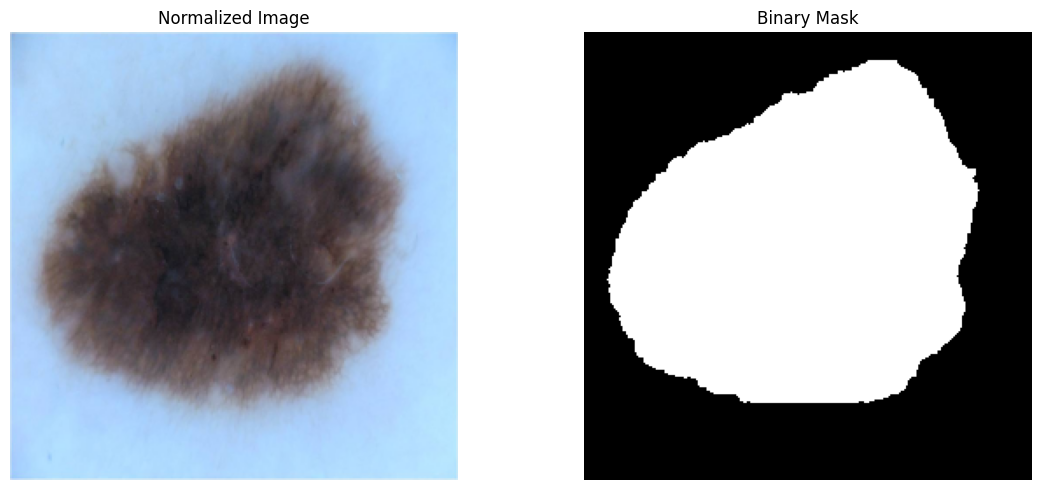

In [21]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_normalized)
plt.title("Normalized Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask_binary, cmap="gray")
plt.title("Binary Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

## Preprocess the complete dataset

In [22]:
# Preprocess all images and masks

X = []
Y = []

for i, image_path in enumerate(image_paths):

    # Load image
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Resize image
    image = cv2.resize(
        image,
        (IMG_WIDTH, IMG_HEIGHT),
        interpolation=cv2.INTER_AREA
    )

    # Normalize image
    image = image.astype(np.float32) / 255.0

    # Load corresponding mask
    image_id = image_path.stem
    mask_path = MASK_DIR / f"{image_id}_Segmentation.png"

    mask = cv2.imread(
        str(mask_path),
        cv2.IMREAD_GRAYSCALE
    )

    # Resize mask
    mask = cv2.resize(
        mask,
        (IMG_WIDTH, IMG_HEIGHT),
        interpolation=cv2.INTER_NEAREST
    )

    # Convert mask from 0/255 to 0/1
    mask = (mask > 0).astype(np.float32)

    # Add to lists
    X.append(image)
    Y.append(mask)

    if (i + 1) % 100 == 0:
        print(f"Processed {i + 1}/{len(image_paths)} images")

# Convert lists to NumPy arrays
X = np.array(X, dtype=np.float32)
Y = np.array(Y, dtype=np.float32)

print("\nPreprocessing complete!")
print("X shape:", X.shape)
print("Y shape:", Y.shape)

Processed 100/900 images
Processed 200/900 images
Processed 300/900 images
Processed 400/900 images
Processed 500/900 images
Processed 600/900 images
Processed 700/900 images
Processed 800/900 images
Processed 900/900 images

Preprocessing complete!
X shape: (900, 256, 256, 3)
Y shape: (900, 256, 256)


In [23]:
# Add a channel dimension to the masks

Y = np.expand_dims(Y, axis=-1)

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (900, 256, 256, 3)
Y shape: (900, 256, 256, 1)


## tarin val test split

In [24]:
from sklearn.model_selection import train_test_split

# First split: 80% training, 20% temporary
X_train, X_temp, Y_train, Y_temp = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42
)

# Second split: divide temporary data equally
# 10% validation and 10% test
X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp,
    Y_temp,
    test_size=0.50,
    random_state=42
)

print("Training images:", X_train.shape)
print("Training masks :", Y_train.shape)

print("Validation images:", X_val.shape)
print("Validation masks :", Y_val.shape)

print("Test images:", X_test.shape)
print("Test masks :", Y_test.shape)

Training images: (720, 256, 256, 3)
Training masks : (720, 256, 256, 1)
Validation images: (90, 256, 256, 3)
Validation masks : (90, 256, 256, 1)
Test images: (90, 256, 256, 3)
Test masks : (90, 256, 256, 1)


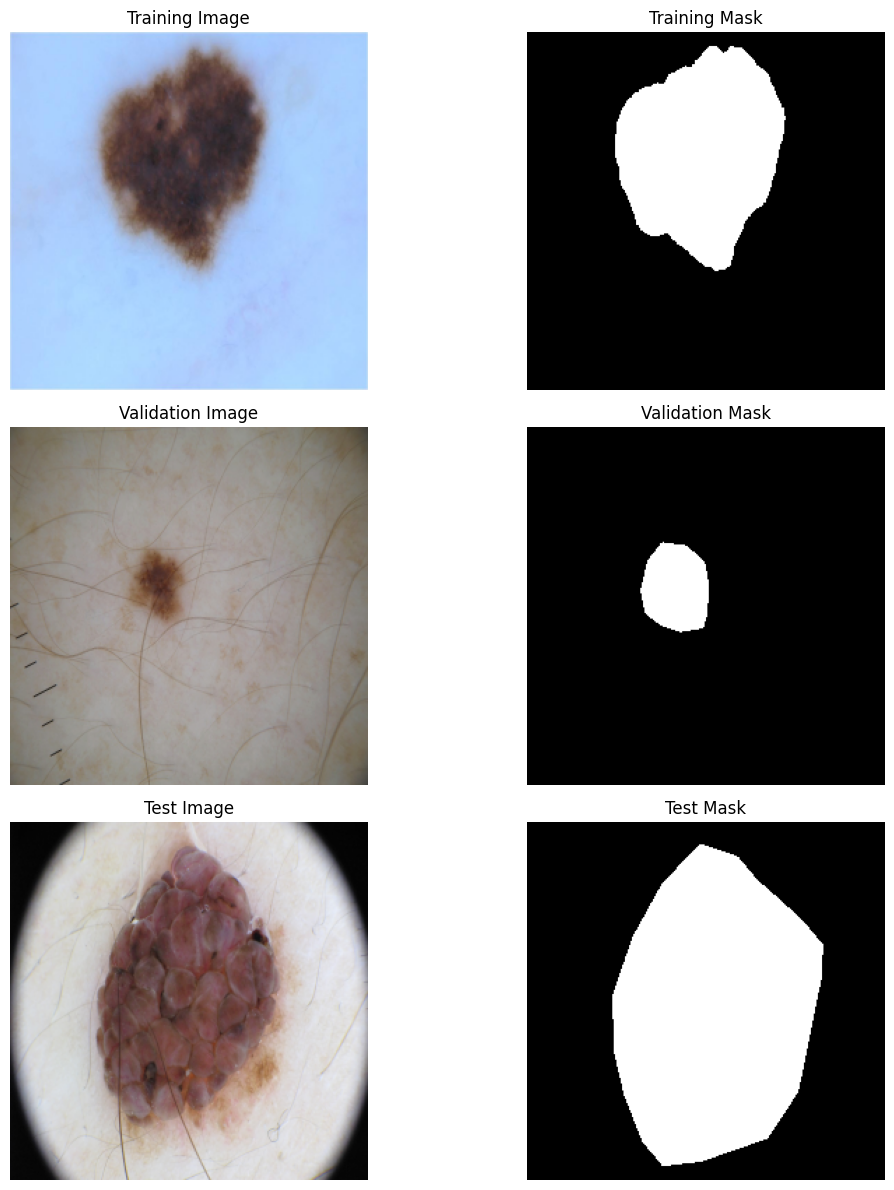

In [25]:
# Visualize one sample from each dataset split

plt.figure(figsize=(12, 12))

# Training sample
plt.subplot(3, 2, 1)
plt.imshow(X_train[0])
plt.title("Training Image")
plt.axis("off")

plt.subplot(3, 2, 2)
plt.imshow(Y_train[0].squeeze(), cmap="gray")
plt.title("Training Mask")
plt.axis("off")

# Validation sample
plt.subplot(3, 2, 3)
plt.imshow(X_val[0])
plt.title("Validation Image")
plt.axis("off")

plt.subplot(3, 2, 4)
plt.imshow(Y_val[0].squeeze(), cmap="gray")
plt.title("Validation Mask")
plt.axis("off")

# Test sample
plt.subplot(3, 2, 5)
plt.imshow(X_test[0])
plt.title("Test Image")
plt.axis("off")

plt.subplot(3, 2, 6)
plt.imshow(Y_test[0].squeeze(), cmap="gray")
plt.title("Test Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

In [26]:
# Save the preprocessed dataset for Notebook 2

np.save("../data/X_train.npy", X_train)
np.save("../data/Y_train.npy", Y_train)

np.save("../data/X_val.npy", X_val)
np.save("../data/Y_val.npy", Y_val)

np.save("../data/X_test.npy", X_test)
np.save("../data/Y_test.npy", Y_test)

print("Preprocessed datasets saved successfully!")

Preprocessed datasets saved successfully!


In [27]:
from pathlib import Path

for file in Path("../data").glob("*.npy"):
    print(file.name, f"{file.stat().st_size / (1024**2):.1f} MB")

X_test.npy 67.5 MB
X_train.npy 540.0 MB
X_val.npy 67.5 MB
Y_test.npy 22.5 MB
Y_train.npy 180.0 MB
Y_val.npy 22.5 MB


In [28]:
X_check = np.load("../data/X_train.npy")

print(X_check.shape)
print(X_check.dtype)

(720, 256, 256, 3)
float32
